**<h1 align="center">Deep Learning Project</h1>**

**Group members:**<br>
Diogo Carvalho - 20240694 <br>
Ricardo Pereira - 20240745 <br>
Rúben Marques - 20240352 <br>
Tomás Carvalho - 20240938

# 1. Imports & Config

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy import ndarray
from matplotlib.pyplot import subplots, show
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, top_k_accuracy_score

# bias
from collections import Counter


# model building imports
import tensorflow as tf
import keras
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import LeakyReLU
from keras.ops import add
from keras.utils import to_categorical
from keras.optimizers import SGD
from keras.optimizers import Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score, TopKCategoricalAccuracy
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler ,ReduceLROnPlateau, EarlyStopping
from keras.utils import Sequence, load_img, img_to_array


# image filtering
from tensorflow.keras.applications import ResNet50, EfficientNetB6,EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from keras.utils import load_img, img_to_array
from tqdm import tqdm  # progress bar

#import keras_tuner
# augmentation operations
from keras.layers import RandomBrightness, RandomFlip, RandomRotation, RandomContrast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Dense, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from keras.layers import Pipeline
from keras.layers import BatchNormalization
from keras.layers import Dropout
from keras.applications import ResNet50
from keras.applications import EfficientNetV2S
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from keras.initializers import Constant

In [ ]:
# List all physical GPUs
gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
print('num gpus:', len(tf.config.list_physical_devices('GPU')))

num gpus: 1


In [11]:
tf.config.run_functions_eagerly(True)

In [12]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set")
    except RuntimeError as e:
        print(e)

Memory growth set


In [13]:
# importing the dataset
# metadata = pd.read_csv('../rare_species 1/metadata.csv')
# metadata = pd.read_csv('../Data/rare_species/metadata.csv')
# metadata.sample(5)

In [4]:

from google.colab import drive
drive.mount('/content/drive')
metadata = pd.read_csv('drive/MyDrive/rare_species/metadata.csv')
metadata.sample(5)

Mounted at /content/drive


,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path
9080,1eb0d760-6650-4574-868d-2639c136d6f6,14006434,47048632,animalia,chordata,vombatidae,chordata_vombatidae/14006434_47048632_eol-full...
4690,ead7666b-81e6-417f-97ff-150e51b13fb7,22565879,45512273,animalia,chordata,trochilidae,chordata_trochilidae/22565879_45512273_eol-ful...
3694,c3be2190-ecd7-46e1-a8a7-f4d185c59223,28756082,45516974,animalia,chordata,paradisaeidae,chordata_paradisaeidae/28756082_45516974_eol-f...
2864,0bf0fe84-c522-407c-a07a-ba3aeb4db509,21062141,4472389,animalia,chordata,atelidae,chordata_atelidae/21062141_4472389_eol-full-si...
322,f9715a0d-e54a-45b5-846a-8894724a5743,8875094,311570,animalia,chordata,hyaenidae,chordata_hyaenidae/8875094_311570_eol-full-siz...


In [5]:
# applying the filepath
# metadata['file_path'] = metadata['file_path'].apply(lambda x: os.path.join('../rare_species 1', x))

metadata['file_path'] = metadata['file_path'].apply(lambda x: os.path.join('drive/MyDrive/rare_species', x))

In [6]:
metadata.sample(5)

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path
4962,d6317063-232e-4918-9704-c143f46d7939,28675224,795885,animalia,chordata,dactyloidae,drive/MyDrive/rare_species/chordata_dactyloida...
4908,a6c4acfd-9f0b-490e-99d8-6286a3f64465,28237305,4453261,animalia,chordata,aotidae,drive/MyDrive/rare_species/chordata_aotidae/28...
44,692d4cd1-e944-44af-a855-c7bfc0c5473f,20080363,46579618,animalia,chordata,serranidae,drive/MyDrive/rare_species/chordata_serranidae...
11621,99b66e64-a7f4-4d39-b4c6-00a0cf582152,22037269,795885,animalia,chordata,dactyloidae,drive/MyDrive/rare_species/chordata_dactyloida...
10991,8188bb2f-e849-4bd1-a816-1696012ab875,20738647,46559412,animalia,chordata,pontoporiidae,drive/MyDrive/rare_species/chordata_pontoporii...


# 2.  Preprocessing

In [7]:
metadata.phylum.unique()

array(['mollusca', 'chordata', 'arthropoda', 'echinodermata', 'cnidaria'],
      dtype=object)

In [8]:
print(metadata['family'].value_counts())

family
dactyloidae        300
cercopithecidae    300
formicidae         291
carcharhinidae     270
salamandridae      270
                  ... 
cyprinodontidae     30
alligatoridae       30
balaenidae          30
goodeidae           30
siluridae           29
Name: count, Length: 202, dtype: int64


In [9]:
num_classes = metadata['family'].nunique()
num_classes

202

our dataset is inbalaced and has a length of 202 classes

In [10]:
# Transforming our target and feature into a int
label_encoder = LabelEncoder()
metadata['target'] = label_encoder.fit_transform(metadata['family'])


In [11]:
metadata['target'].sample(10)

,target
887,193
9972,156
10067,1
330,196
10195,143
11764,2
5432,62
5278,84
3787,95
5756,139


## Cheking for misslabeled images/ images that are not supposed to be in our dataset

Even with False Positives the objective is to not discard more than 5% of our dataset

In [12]:
model = EfficientNetB0(weights="imagenet", include_top=True)

#From imagenet class index:https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json
animal_prefixes = ('n014', 'n015', 'n016', 'n017', 'n018', 'n019', 'n020', 'n021', 'n022', 'n023', 'n024')


weird_samples = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    path = row['file_path']
    true_label = row['family']

    try:
        img = load_img(path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)

        preds = model.predict(x, verbose=0)
        top_pred = decode_predictions(preds, top=1)[0][0]  # (id, label, prob)

        class_id = top_pred[0]
        prob = top_pred[2]

        # Check if class_id is among animal-related prefixes
        if not class_id.startswith(animal_prefixes) and prob > 0.85:
            print(f"Not animal (class_id={class_id}) → removed: labeled '{true_label}'")
            weird_samples.append((path, class_id, prob, true_label))

    except Exception as e:
        print(f"Error reading {path}: {e}")




21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


  0%|          | 0/11983 [00:00<?, ?it/s]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  1%|▏         | 170/11983 [02:56<2:58:00,  1.11it/s]

Not animal (class_id=n04275548) → removed: labeled 'parulidae'


...

 91%|█████████ | 10899/11983 [2:57:54<18:04,  1.00s/it]

Not animal (class_id=n09229709) → removed: labeled 'atelidae'


 93%|█████████▎| 11189/11983 [3:02:32<13:53,  1.05s/it]

Not animal (class_id=n04118776) → removed: labeled 'agariciidae'


100%|██████████| 11983/11983 [3:15:13<00:00,  1.02it/s]


In [ ]:
len(weird_samples)

55

In [14]:
len(metadata) * 0.05

599.15

Less than 5% like we wanted

In [15]:
# creating a clean dataset
bad_photos = [sample[0] for sample in weird_samples]

clean_metadata = metadata[~metadata['file_path'].isin(bad_photos)]

In [16]:
print(len(clean_metadata))
print(len(metadata))

11928
11983


In [ ]:
# clean_metadata = pd.read_csv('drive/MyDrive/rare_species/clean_metadata.csv')
# clean_metadata['file_path'] = clean_metadata['file_path'].str.replace('../rare_species 1/', 'drive/MyDrive/rare_species/', regex=False)

# clean_metadata['target'] = le.transform(metadata_clean['family'])



In [17]:
clean_metadata.sample(5)

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path,target
3889,5a52ab01-f6ad-45c7-b9f4-7d7bd7bb0a2c,28675264,795885,animalia,chordata,dactyloidae,drive/MyDrive/rare_species/chordata_dactyloida...,60
5312,c6ae132d-105e-4f00-9960-f05aa4639271,20715741,45276801,animalia,cnidaria,merulinidae,drive/MyDrive/rare_species/cnidaria_merulinida...,116
6697,43bd570f-9c34-4895-9ead-956937f8ad30,29638459,476649,animalia,arthropoda,formicidae,drive/MyDrive/rare_species/arthropoda_formicid...,79
10704,65d66d64-0af8-4750-b691-c159569f848e,8860854,46559202,animalia,chordata,otariidae,drive/MyDrive/rare_species/chordata_otariidae/...,126
761,9b3b61cf-b9d9-4de0-a2fc-b087a2d0bf92,20577178,4453333,animalia,chordata,cebidae,drive/MyDrive/rare_species/chordata_cebidae/20...,36


Now let's compare both Df families

In [18]:
# Get value counts per class
old_counts = metadata['family'].value_counts().rename("before_cleaning")
new_counts = clean_metadata['family'].value_counts().rename("after_cleaning")

# Combine into a DataFrame
comparison_df = pd.concat([old_counts, new_counts], axis=1).fillna(0).astype(int)

# Add difference column
comparison_df['removed'] = comparison_df['before_cleaning'] - comparison_df['after_cleaning']

# Sort by most affected classes
comparison_df = comparison_df.sort_values(by='removed', ascending=False)


pd.set_option('display.max_rows', None)
display(comparison_df)


,before_cleaning,after_cleaning,removed
family,,,
agariciidae,120,112,8
salamandridae,270,267,3
plethodontidae,270,267,3
acipenseridae,90,88,2
pocilloporidae,60,58,2
alopiidae,60,58,2
ramphastidae,30,28,2
dactyloidae,300,299,1
diomedeidae,180,179,1


### Spliting the data

In [19]:
# Spliting the data while keeping the same distribuition of classes(target) - 70%/20%/10%

train, temp = train_test_split(clean_metadata, test_size=0.3,stratify=clean_metadata['target'],random_state=1)

val, test = train_test_split(temp,test_size=1/3,stratify=temp['target'],random_state=1)

In [20]:
train.shape , val.shape , test.shape

((8349, 8), (2386, 8), (1193, 8))

Loading the images

In [ ]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def df_to_dataset(dataframe):
    filepaths = dataframe['file_path'].values
    labels = dataframe['target'].values

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def process(file_path, label):
        image = tf.io.read_file(file_path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32) / 255.0
        return image, tf.one_hot(label, depth=num_classes)

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [23]:
train_df = df_to_dataset(train)
val_df = df_to_dataset(val)
test_df = df_to_dataset(test)

# 3. Models

In [24]:
augmentation_layer = Sequential(
    [
        RandomBrightness(factor=0.2, value_range=(0.0, 1.0)),
        RandomFlip(),
        RandomRotation(factor=0.2, fill_mode="reflect"),
        RandomContrast(factor = 0.4, value_range=(0, 1), seed=1)
    ],
    name="augmentation_layer")


In [ ]:
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0, verbose = 1)

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights = True)

In [ ]:
from re import T
loss = CategoricalCrossentropy(name="loss")

# metrics
# important to mention that we will only take in account the f1-score when making decisions between the models, the remaining metrics are present just for visualisation pruposes
categorical_accuracy = CategoricalAccuracy(name="accuracy")
f1_score = F1Score(average="macro", name="f1_score")
top_5_accuracy = TopKCategoricalAccuracy(k=5, name="top_5_accuracy")
metrics = [categorical_accuracy, f1_score, top_5_accuracy]

In [28]:
input_shape = (256, 256,3)

epochs = 200
batch_size = 32

## CNN 1

In [ ]:
def build_CNN(input_shape, num_classes):
    weight_decay = 1e-4

    model = Sequential([
        Input(shape=input_shape),
        augmentation_layer,
        
        # first layer
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # second layer
        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # third layer
        Conv2D(256, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # fourth layer
        Conv2D(256, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # fifth layer
        Conv2D(512, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # sixth layer
        Conv2D(512, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),
        Dropout(0.4),

        # seventh layer
        Conv2D(512, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),

        # Transition to Dense layers
        GlobalAveragePooling2D(),

        # Dense layers
        Dense(1024, activation="relu"),
        Dropout(0.5),


        Dense(512, activation="relu"),
        Dropout(0.3),

        # final output layer
        Dense(num_classes, activation="softmax")
    ], name="CNN_1")

    model.summary()
    return model




In [46]:
model_1 = build_CNN(input_shape=input_shape, num_classes=num_classes)

optimizer = SGD(learning_rate=0.01, name="optimizer")

model_1.compile(loss=loss, optimizer=optimizer, metrics=metrics)

Model: "CNN_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_layer (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,80

 Total params: 8,023,370 (30.61 MB)

 Trainable params: 8,018,890 (30.59 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [47]:
# train the model
_1 = model_1.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=[lr_reduction, early_stop],
    verbose=1
)

Epoch 1/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 69s 256ms/step - accuracy: 0.1211 - f1_score: 0.0986 - loss: 5.3770 - top_5_accuracy: 0.2578 - val_accuracy: 0.0247 - val_f1_score: 7.0390e-04 - val_loss: 5.2743 - val_top_5_accuracy: 0.1228 - learning_rate: 0.0100
Epoch 2/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 67s 254ms/step - accuracy: 0.0600 - f1_score: 0.0065 - loss: 5.0625 - top_5_accuracy: 0.1755 - val_accuracy: 0.0415 - val_f1_score: 0.0047 - val_loss: 5.1405 - val_top_5_accuracy: 0.1429 - learning_rate: 0.0100
Epoch 3/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 66s 253ms/step - accuracy: 0.0734 - f1_score: 0.0083 - loss: 4.9448 - top_5_accuracy: 0.1875 - val_accuracy: 0.0696 - val_f1_score: 0.0088 - val_loss: 4.9696 - val_top_5_accuracy: 0.1735 - learning_rate: 0.0100
Epoch 4/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 67s 255ms/step - accuracy: 0.0889 - f1_score: 0.0122 - loss: 4.8276 - top_5_accuracy: 0.2063 - val_accuracy: 0.0872 - val_f1_score: 0.0128 - val_loss: 4.7781 - val_top_5_accuracy: 0.2263 - learning_r

In [94]:
model_1_eva = model_1.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.2070 - f1_score: 0.1272 - loss: 3.8268 - top_5_accuracy: 0.4630


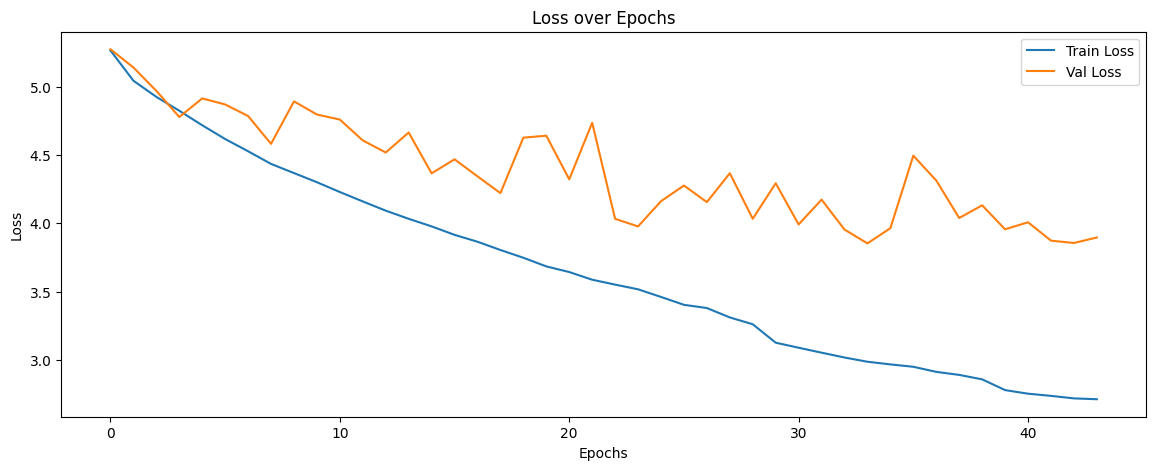

In [ ]:
plt.figure(figsize=(14, 5))

# Plotting training and validation loss
plt.plot(_1.history['loss'], label='Train Loss')
plt.plot(_1.history['val_loss'], label='Val Loss')

# Adding title and labels
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## CNN 2

In [ ]:
def build_CNN(input_shape, num_classes):
    weight_decay = 1e-4

    model = Sequential([
        Input(shape=input_shape),
        augmentation_layer,

        # first layer
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # second layer
        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # third layer
        Conv2D(256, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # fourth layer
        Conv2D(256, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # fifth layer
        Conv2D(512, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # sixth layer
        Conv2D(512, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),
        Dropout(0.4),

        # seventh layer
        Conv2D(512, (3, 3), activation="relu", kernel_regularizer=l2(weight_decay)),
        BatchNormalization(),

        # Transition to Dense layers
        GlobalAveragePooling2D(),

        # Dense layers/ fully connected layers
        Dense(1024, activation="relu"),
        Dropout(0.5),


        Dense(512, activation="relu"),
        Dropout(0.3),

        # final output layer
        Dense(num_classes, activation="softmax")
    ], name="CNN_2")

    model.summary()
    return model




In [43]:
model_2 = build_CNN(input_shape=input_shape, num_classes=num_classes)

optimizer = Adam(learning_rate= 1e-4, name="optimizer")

model_2.compile(loss=loss, optimizer=optimizer, metrics=metrics)

Model: "CNN_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_layer (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 2, 2, 512)      │         2,04

 Total params: 8,023,370 (30.61 MB)

 Trainable params: 8,018,890 (30.59 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [44]:
# train the model
_2 = model_2.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=[lr_reduction, early_stop],
    verbose=1
)

Epoch 1/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 75s 262ms/step - accuracy: 0.0976 - f1_score: 0.0498 - loss: 5.3971 - top_5_accuracy: 0.2309 - val_accuracy: 0.0147 - val_f1_score: 3.7613e-04 - val_loss: 5.7341 - val_top_5_accuracy: 0.0855 - learning_rate: 1.0000e-04
Epoch 2/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 68s 259ms/step - accuracy: 0.0677 - f1_score: 0.0076 - loss: 5.0692 - top_5_accuracy: 0.1735 - val_accuracy: 0.0478 - val_f1_score: 0.0033 - val_loss: 5.1156 - val_top_5_accuracy: 0.1408 - learning_rate: 1.0000e-04
Epoch 3/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 68s 258ms/step - accuracy: 0.0841 - f1_score: 0.0125 - loss: 4.9314 - top_5_accuracy: 0.1946 - val_accuracy: 0.0750 - val_f1_score: 0.0128 - val_loss: 4.8508 - val_top_5_accuracy: 0.2066 - learning_rate: 1.0000e-04
Epoch 4/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 68s 259ms/step - accuracy: 0.0871 - f1_score: 0.0149 - loss: 4.8179 - top_5_accuracy: 0.2051 - val_accuracy: 0.0830 - val_f1_score: 0.0122 - val_loss: 4.7373 - val_top_5_accuracy: 0.2192 

In [93]:
model_2_eva = model_2.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.2516 - f1_score: 0.1753 - loss: 3.6165 - top_5_accuracy: 0.4847


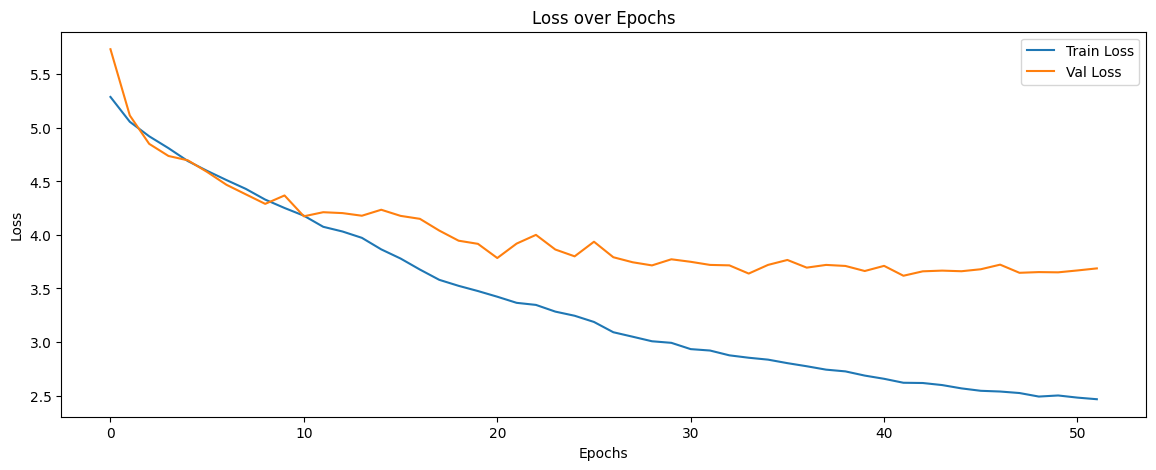

In [ ]:
plt.figure(figsize=(14, 5))

# Plotting the training and validation loss
plt.plot(_2.history['loss'], label='Train Loss')
plt.plot(_2.history['val_loss'], label='Val Loss')

# Adding title and labels
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


## EF 1

The next two models will be based on the pre-trained EfficientNetV2S architecture. Their objective is to evaluate the impact of incorporating class-distribution-based initial bias in the output layer, aiming to help the model produce better predictions in training.

https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

In [ ]:
def build_efficientnetv2s_model(input_shape=input_shape, num_classes=num_classes):
    inputs = Input(shape=input_shape, name="input_layer")
    x = augmentation_layer(inputs) # Apply augmentation before the base model

    # Add EfficientNetV2S base model
    base_model = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        include_preprocessing=True
    ) 
    base_model.trainable = True

    # Passing the augmented input to the base model
    x = base_model(x)

    # Reducing spatial dimensions 
    x = GlobalAveragePooling2D()(x)
    
    # Adding dropout to prevent overfit and fully connected dense layers 
    x = Dropout(0.5)(x)
    x = Dense(1024, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=output, name="EfficientNetV2S_Custom")
    return model



In [73]:
# This is a model that learns faster than the others so we will define a lower patience to prevent overfitting

lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0, verbose = 1)
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4, restore_best_weights = True)

In [74]:
effnet = build_efficientnetv2s_model(input_shape=input_shape, num_classes=num_classes)
effnet.summary()

effnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss,
    metrics=metrics)


Model: "EfficientNetV2S_Custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_layer (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 202)            │       207,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,850,154 (83.35 MB)

 Trainable params: 21,696,282 (82.76 MB)

 Non-trainable params: 153,872 (601.06 KB)

In [ ]:
# Train the model
_3 = effnet.fit(
    train_df,
    validation_data=val_df,
    epochs=100,
    callbacks=[early_stop, lr_reduction],
    verbose=1
)

Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 225s 506ms/step - accuracy: 0.0856 - f1_score: 0.0379 - loss: 5.1171 - top_5_accuracy: 0.1917 - val_accuracy: 0.2234 - val_f1_score: 0.0584 - val_loss: 4.1595 - val_top_5_accuracy: 0.4279 - learning_rate: 1.0000e-04
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 126s 480ms/step - accuracy: 0.2094 - f1_score: 0.0531 - loss: 3.9711 - top_5_accuracy: 0.3959 - val_accuracy: 0.3839 - val_f1_score: 0.1820 - val_loss: 2.9245 - val_top_5_accuracy: 0.6614 - learning_rate: 1.0000e-04
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 126s 481ms/step - accuracy: 0.3448 - f1_score: 0.1594 - loss: 2.9493 - top_5_accuracy: 0.6099 - val_accuracy: 0.5092 - val_f1_score: 0.3330 - val_loss: 2.0989 - val_top_5_accuracy: 0.7758 - learning_rate: 1.0000e-04
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 126s 482ms/step - accuracy: 0.4674 - f1_score: 0.2991 - loss: 2.2142 - top_5_accuracy: 0.7495 - val_accuracy: 0.5377 - val_f1_score: 0.4195 - val_loss: 1.9164 - val_top_5_accuracy: 0.7888 

In [80]:
ef_eva1 = effnet.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.7190 - f1_score: 0.6079 - loss: 1.1940 - top_5_accuracy: 0.8899


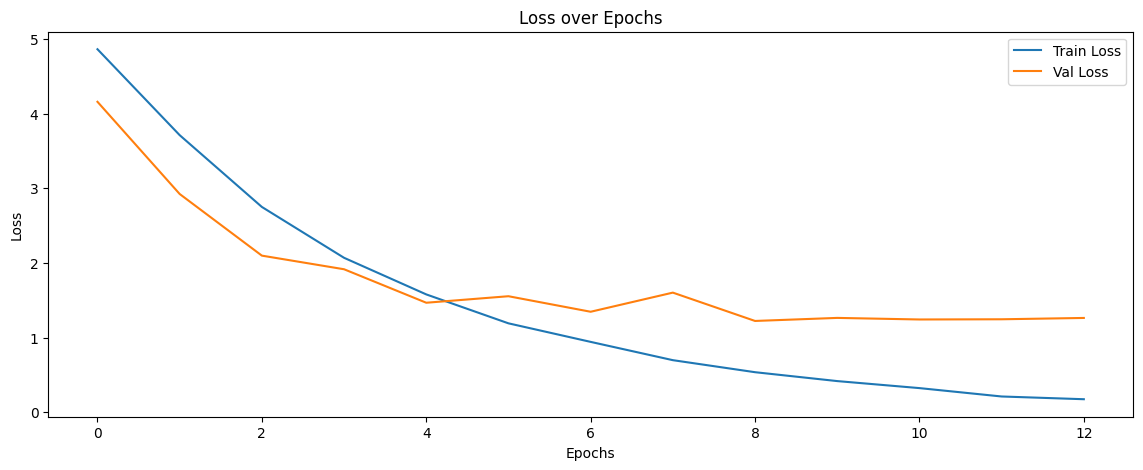

In [ ]:
plt.figure(figsize=(14, 5))

# Plot training and validation loss
plt.plot(_3.history['loss'], label='Train Loss')
plt.plot(_3.history['val_loss'], label='Val Loss')

# Adding title and labels
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Let's add some weights to the classes that are having trouble in the predictions

## EF 2

With bias

In [51]:
# adding bias as seen in the tensorflow website https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

# Count images per class
counts = clean_metadata['target'].value_counts().sort_index()  # must be sorted to match class indices
total = np.sum(counts)

# Compute log priors
initial_bias = np.log(counts / total)


In [ ]:
def build_efficientnetv2s_model(input_shape=input_shape, num_classes=num_classes):
    inputs = Input(shape=input_shape, name="input_layer")
    x = augmentation_layer(inputs) # Apply augmentation before the base model

    # EfficientNetV2S base model
    base_model = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        include_preprocessing=True
    )
    base_model.trainable = True # Make it trainable

    # Pass augmented input through base model
    x = base_model(x)

    # Reduce spatial dimensions adding dropout to prevent overfit and fully connected dense layers
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(1024, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation="softmax", bias_initializer=Constant(initial_bias))(x)

    # Build full model using correct input/output
    model = Model(inputs=inputs, outputs=output, name="EfficientNetV2S_Custom_with_bias")
    return model


In [86]:
effnet_v2 = build_efficientnetv2s_model(input_shape=input_shape, num_classes=num_classes)
effnet_v2.summary()

effnet_v2.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics)


Model: "EfficientNetV2S_Custom_with_bias"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_layer (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 202)            │       207,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,850,154 (83.35 MB)

 Trainable params: 21,696,282 (82.76 MB)

 Non-trainable params: 153,872 (601.06 KB)

In [87]:
_4 = effnet_v2.fit(
    train_df,
    validation_data=val_df,
    epochs=200,
    callbacks=[early_stop, lr_reduction],
    verbose=1,
)

Epoch 1/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 223s 504ms/step - accuracy: 0.6097 - f1_score: 0.6998 - loss: 4.9859 - top_5_accuracy: 0.6744 - val_accuracy: 0.1651 - val_f1_score: 0.0219 - val_loss: 4.3594 - val_top_5_accuracy: 0.3001 - learning_rate: 1.0000e-04
Epoch 2/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 125s 479ms/step - accuracy: 0.1825 - f1_score: 0.0381 - loss: 4.1561 - top_5_accuracy: 0.3465 - val_accuracy: 0.3189 - val_f1_score: 0.1174 - val_loss: 3.0836 - val_top_5_accuracy: 0.5884 - learning_rate: 1.0000e-04
Epoch 3/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 125s 479ms/step - accuracy: 0.3269 - f1_score: 0.1540 - loss: 3.0347 - top_5_accuracy: 0.5897 - val_accuracy: 0.4891 - val_f1_score: 0.3266 - val_loss: 2.0900 - val_top_5_accuracy: 0.7699 - learning_rate: 1.0000e-04
Epoch 4/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 125s 479ms/step - accuracy: 0.4538 - f1_score: 0.3032 - loss: 2.2479 - top_5_accuracy: 0.7425 - val_accuracy: 0.5373 - val_f1_score: 0.4186 - val_loss: 1.8459 - val_top_5_accuracy: 0.8068 

In [96]:
ef_eva2 = effnet_v2.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.7208 - f1_score: 0.6090 - loss: 1.1436 - top_5_accuracy: 0.8976


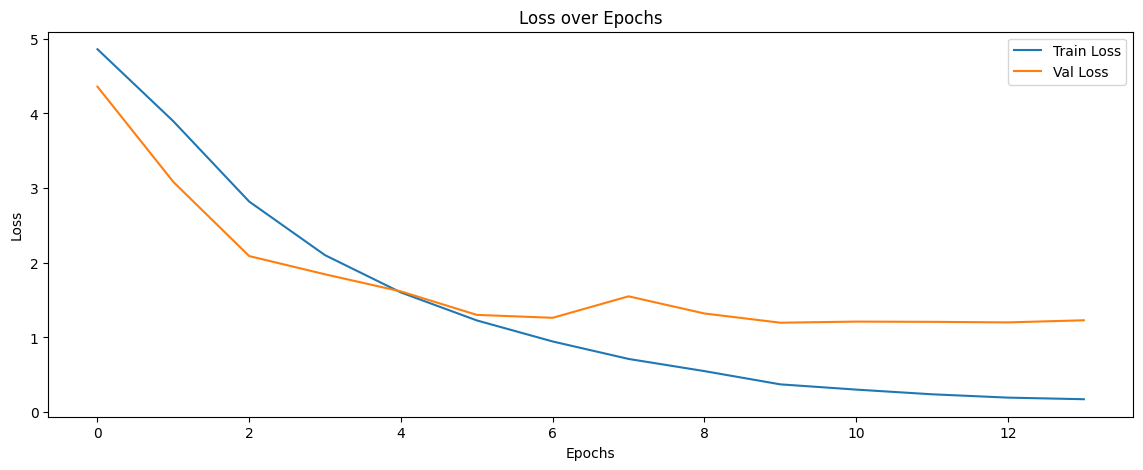

In [ ]:

plt.figure(figsize=(14, 5))

# Plot training and validation loss
plt.plot(_4.history['loss'], label='Train Loss')
plt.plot(_4.history['val_loss'], label='Val Loss')

# Adding title and labels
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## ResNet50

In the following model, our approach was to first train the models with frozen layers to allow them to adapt to our images, and then unfreeze the layers to let the models fine-tune and find the best overall weights for our problem. But due to a problem with google colab and time this was not possible so the strategy in this model was to adapt the final layers to our problem and to try and see if the frozen model would adapt to our task.

Due to the problem menctioned before this approach as an identical struture as the one that is usually identified in that type of approach.



In [34]:
# https://keras.io/guides/transfer_learning/

In [ ]:
# redefine the callback with a higher patience
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0, verbose = 1)
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights = True)

In [ ]:
def build_resnet50_model(input_shape=input_shape, num_classes=num_classes):
    inputs = Input(shape=input_shape, name="input_layer")
    x = augmentation_layer(inputs)  # Apply augmentation 

    # ResNet50 base model
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze base model

    # Pass augmented input through base model
    x = base_model(x)

    # Reducing spatial dimensions
    x = GlobalAveragePooling2D()(x)
    
      # Added dropout and fully conected dense layers along with batchnormalization
    x = Dense(1024, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', bias_initializer=Constant(initial_bias))(x)

    model = Model(inputs=inputs, outputs=outputs, name="ResNet50_Custom")
    return model


resnet50 = build_resnet50_model(input_shape=input_shape, num_classes=num_classes)

In [53]:
resnet50.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=CategoricalCrossentropy(),
    metrics=metrics)


In [54]:
_6 = resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=40,
    callbacks=[early_stop, lr_reduction],
    verbose=1,
    #class_weight=class_weights_dict
)

Epoch 1/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 45s 137ms/step - accuracy: 0.1061 - f1_score: 0.0790 - loss: 5.7420 - top_5_accuracy: 0.2500 - val_accuracy: 0.0373 - val_f1_score: 0.0025 - val_loss: 5.0229 - val_top_5_accuracy: 0.1391 - learning_rate: 1.0000e-04
Epoch 2/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 122ms/step - accuracy: 0.0323 - f1_score: 0.0065 - loss: 5.3952 - top_5_accuracy: 0.1156 - val_accuracy: 0.0444 - val_f1_score: 0.0037 - val_loss: 4.9948 - val_top_5_accuracy: 0.1467 - learning_rate: 1.0000e-04
Epoch 3/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.0397 - f1_score: 0.0125 - loss: 5.2483 - top_5_accuracy: 0.1398 - val_accuracy: 0.0444 - val_f1_score: 0.0052 - val_loss: 4.9407 - val_top_5_accuracy: 0.1693 - learning_rate: 1.0000e-04
Epoch 4/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 121ms/step - accuracy: 0.0446 - f1_score: 0.0124 - loss: 5.1502 - top_5_accuracy: 0.1454 - val_accuracy: 0.0436 - val_f1_score: 0.0118 - val_loss: 4.8602 - val_top_5_accuracy: 0.1681 - learni

In [ ]:
# # Unfreezing some layers of ResNet50
# for layer in model.layers:
#         if not isinstance(layer, layers.BatchNormalization):
#             layer.trainable = True

resnet50.compile(
    optimizer=Adam(learning_rate=1e-5),
    metrics=metrics
)


resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=[early_stop, lr_reduction],
    verbose=1,
)


Epoch 1/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 43s 133ms/step - accuracy: 0.1284 - f1_score: 0.0690 - loss: 4.1599 - top_5_accuracy: 0.3075 - val_accuracy: 0.1253 - val_f1_score: 0.0553 - val_loss: 4.3037 - val_top_5_accuracy: 0.2967 - learning_rate: 1.0000e-05
Epoch 2/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.1281 - f1_score: 0.0674 - loss: 4.1691 - top_5_accuracy: 0.2991 - val_accuracy: 0.1274 - val_f1_score: 0.0563 - val_loss: 4.3082 - val_top_5_accuracy: 0.2988 - learning_rate: 1.0000e-05
Epoch 3/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 122ms/step - accuracy: 0.1296 - f1_score: 0.0721 - loss: 4.1482 - top_5_accuracy: 0.3177 - val_accuracy: 0.1320 - val_f1_score: 0.0622 - val_loss: 4.2949 - val_top_5_accuracy: 0.3005 - learning_rate: 1.0000e-05
Epoch 4/200
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 122ms/step - accuracy: 0.1305 - f1_score: 0.0654 - loss: 4.1373 - top_5_accuracy: 0.3204 - val_accuracy: 0.1345 - val_f1_score: 0.0645 - val_loss: 4.2875 - val_top_5_accuracy: 0.3030 - le

In [56]:
rn50_eva = resnet50.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.1324 - f1_score: 0.0577 - loss: 4.2695 - top_5_accuracy: 0.3146


In [67]:
efnv2stl_eva = effnetv2s_tl.evaluate(val_df, verbose=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.1262 - f1_score: 0.0629 - loss: 4.3810 - top_5_accuracy: 0.2698


# 4. Results and Predictions

For the training F1-score, the value from the best training epoch was retrieved, while the validation F1-score was determined through a final evaluation across all models.

| Metric    | CNN 1 | CNN 2 | EF 1 | EF 2 | RN50 |
|-----------|-----------------------------------------------|----------------------------------------------|---------------------------------------------|--------------------------------------|-------------------------------------|
| F1 Train  | 0.2815                                        | 0.3159                                       | 0.7725                                      | 0.8487                               | 0.0742                              |
| F1 Val    | 0.1712                                        | 0.2028                                       | 0.6079                                      | 0.6090                               | 0.0577                  

With this, we chose Model 3 as our final model because it had similar validation performance as model 4 but a lower training F1-score, indicating that it had not yet started overfitting.

For the other models, Models CNN 1 and CNN 2 had satisfactory results, and for future work, more layers could be added to improve their performance. For RN50, the results were disappointing, meaning that a different strategy should be applied, such as unfreezing all the layers,or partially unfreezing some layers.

Overall, future work could include using Keras Tuner more extensively to explore a wider range of hyperparameter combinations for each model. Additionally, other models could be tested, especially more efficient ones with higher performance scores that are present in the Keras API and more techniques could be explored, along with alternative implementations of the ones already used.

As for the predictions, the model still has difficulty identifying the classes with lower representation in the dataset. Therefore, another direction for future work would be to search for and include more samples of those underrepresented classes.

In [ ]:
# Evaluating the final model with unseen data
final_evaluation = effnet.evaluate(test_df, verbose=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.6868 - f1_score: 0.5207 - loss: 1.3682 - top_5_accuracy: 0.8548


In [ ]:
y_prob = effnet.predict(test_df, verbose=1)      # shape: (N, 202)
y_pred = np.argmax(y_prob, axis=1)               # predicted class ids, converts to predicted label index

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step


In [ ]:
y_true = test['target'].values   # true class ids

assert len(y_true) == len(y_pred), "mismatch in lengths!"

In [106]:
target_names = label_encoder.classes_

report_df = (
    pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            output_dict=True,
            zero_division=0
        )
    )
    .transpose()
    .drop(index=["accuracy", "macro avg", "weighted avg"])
    .sort_values("f1-score")
)

pd.set_option("display.max_rows", None)
display(report_df)


,precision,recall,f1-score,support
alligatoridae,0.000000,0.000000,0.000000,3.0
balaenicipitidae,0.000000,0.000000,0.000000,3.0
dalatiidae,0.000000,0.000000,0.000000,3.0
chelydridae,0.000000,0.000000,0.000000,3.0
gavialidae,0.000000,0.000000,0.000000,3.0
gymnuridae,0.000000,0.000000,0.000000,3.0
dasyuridae,0.000000,0.000000,0.000000,3.0
pangasiidae,0.000000,0.000000,0.000000,3.0
soricidae,0.000000,0.000000,0.000000,3.0
pristidae,0.000000,0.000000,0.000000,3.0


As for the predictions we can verify that the model still has some difficulty in identifying the classes with a lower presence in the dataset, so another thing that could be done in the future would be to search more samples of those classes